# Supervised Learning: Case 2 - Predicting Layoffs (Binary Classification)
**MLCOE Probation Task 2**

In this notebook, we build, evaluate, and compare four classification models to predict whether a tech job posting is associated with a company layoff within 12 months:
1. **Logistic Regression** (Linear probabilistic model with Sigmoid & Log-Loss)
2. **Decision Tree Classifier** (Non-parametric tree based on Gini/Entropy impurity)
3. **Support Vector Machine - Linear Kernel** (Margin maximization with linear decision boundary)
4. **Support Vector Machine - RBF Kernel** (Non-linear kernel trick projecting into infinite-dimensional space)

We implement shared preprocessing, address severe target class imbalance, apply feature scaling with `StandardScaler`, evaluate on a stratified test set using Accuracy, Precision, Recall, and F1-Score, visualize confusion matrices, and provide in-depth mathematical foundations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Aesthetics setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Data Ingestion & Target Variable Justification

### Problem Formulation:
The objective is to predict whether a job posting is associated with a company layoff within 12 months.
The raw dataset contains the field `layoff_within_12_months_flag`. However, this field is unstandardized, recording entries across 8 conflicting string and boolean formats:
- Negative instances (No layoff): `'0'`, `0`, `'False'`, `False`, `'No'`, `'N'`
- Positive instances (Layoff within 12 months): `'1'`, `1`, `'True'`, `True`, `'Yes'`, `'Y'`

We standardize these inconsistent representations into a single binary numerical column `layoff` ($0 = \text{No Layoff}, 1 = \text{Layoff within 12 months}$).

In [2]:
df = pd.read_csv('tech_job_market_2019_2026.csv')
print(f"Dataset Dimensions: {df.shape[0]:,} rows and {df.shape[1]} columns")

print("\nRaw value counts in layoff_within_12_months_flag:")
print(df['layoff_within_12_months_flag'].value_counts(dropna=False))

Dataset Dimensions: 115,000 rows and 28 columns

Raw value counts in layoff_within_12_months_flag:
layoff_within_12_months_flag
N        25170
False    24999
0        24976
No       24780
Y         3818
Yes       3801
1         3764
True      3692
Name: count, dtype: int64


In [3]:
# Standardize the target variable into clean binary 0 and 1
layoff_map = {
    '0': 0, 0: 0, 'False': 0, False: 0, 'No': 0, 'N': 0,
    '1': 1, 1: 1, 'True': 1, True: 1, 'Yes': 1, 'Y': 1
}

df['layoff'] = df['layoff_within_12_months_flag'].map(layoff_map)

print("Standardized binary target distribution:")
target_counts = df['layoff'].value_counts()
print(target_counts)

print(f"\nClass 0 (No Layoff): {target_counts[0]:,} ({target_counts[0]/len(df)*100:.2f}%)")
print(f"Class 1 (Layoff):    {target_counts[1]:,} ({target_counts[1]/len(df)*100:.2f}%)")

Standardized binary target distribution:
layoff
0    99925
1    15075
Name: count, dtype: int64

Class 0 (No Layoff): 99,925 (86.89%)
Class 1 (Layoff):    15,075 (13.11%)


> **Class Balance Check & Interpretation Warning**:
> The target variable exhibits significant **class imbalance**:
> - **Class 0 (No Layoff)**: **86.89%** (99,925 postings)
> - **Class 1 (Layoff within 12 months)**: **13.11%** (15,075 postings)
>
> **Critical Modeling Implication**: A naive baseline model that blindly predicts "No Layoff" for every single job posting would achieve an **86.89% Accuracy** while identifying exactly zero layoffs (0% Recall, 0% Precision). Therefore:
> 1. **Accuracy is a deceptive metric** for this problem.
> 2. Evaluation must focus on **Recall** (catching real layoffs), **Precision** (avoiding false alarms), and the harmonic **F1-Score**.
> 3. During train-test splitting, we must enforce **stratification** (`stratify=y`) so that both partitions preserve the 13.11% positive ratio.
> 4. We use `class_weight='balanced'` in our classifiers to penalize misclassifications of the minority layoff class inversely proportional to class frequencies.

## 2. Feature Engineering & Preprocessing

To predict layoffs, we extract relevant company, macroeconomic, and position features:
1. `posting_year`: Extracted from `posting_date`. Tech industry layoffs surged dramatically during the 2022–2023 macroeconomic tightening cycle.
2. `company_type`: Startup, MNC, FAANG-tier, Mid-size, Unicorn.
3. `sector`: Industry vertical (Crypto/Web3, EdTech, E-commerce, HealthTech, etc.).
4. `company_size_employees`: Headcount scale.
5. `seniority_level`: Intern, Entry, Mid, Senior, Lead, Principal.
6. `work_mode`: Standardized into `Hybrid`, `Remote`, and `Onsite`.
7. `job_location_country`: Country where the position is located.
8. `avg_experience`: Midpoint of experience range: `(years_experience_min + years_experience_max) / 2`.
9. `number_of_interview_rounds`: Number of screening rounds (imputed with median).

In [4]:
# 1. Macroeconomic temporal feature: Year of job posting
df['posting_year'] = pd.to_datetime(df['posting_date']).dt.year

# 2. Standardize work_mode
work_mode_map = {
    'Hybrid': 'Hybrid', 'HYBRID': 'Hybrid', 'hybrid': 'Hybrid',
    'Remote': 'Remote', 'remote': 'Remote', 'REMOTE': 'Remote', 
    'Work From Home': 'Remote', 'WFH': 'Remote',
    'Onsite': 'Onsite', 'ONSITE': 'Onsite', 'onsite': 'Onsite', 
    'In-office': 'Onsite', 'On-site': 'Onsite'
}
df['work_mode'] = df['work_mode'].map(work_mode_map)

# 3. Experience midpoint
df['avg_experience'] = (df['years_experience_min'] + df['years_experience_max']) / 2

# 4. Impute interview rounds missing values with median
df['number_of_interview_rounds'] = df['number_of_interview_rounds'].fillna(df['number_of_interview_rounds'].median()).astype(int)

# 5. Clean string columns
df['company_type'] = df['company_type'].astype(str).str.strip()
df['sector'] = df['sector'].astype(str).str.strip()
df['seniority_level'] = df['seniority_level'].astype(str).str.strip()
df['job_location_country'] = df['job_location_country'].astype(str).str.strip()

feature_cols = [
    'company_type', 'sector', 'company_size_employees', 'seniority_level',
    'work_mode', 'job_location_country', 'avg_experience', 
    'number_of_interview_rounds', 'posting_year'
]

model_df = df[feature_cols + ['layoff']].copy()
print("Modeling DataFrame dimensions:", model_df.shape)
print("Missing values in modeling dataframe:\n", model_df.isnull().sum())
model_df.head()

Modeling DataFrame dimensions: (115000, 10)
Missing values in modeling dataframe:
 company_type                  0
sector                        0
company_size_employees        0
seniority_level               0
work_mode                     0
job_location_country          0
avg_experience                0
number_of_interview_rounds    0
posting_year                  0
layoff                        0
dtype: int64


,company_type,sector,company_size_employees,seniority_level,work_mode,job_location_country,avg_experience,number_of_interview_rounds,posting_year,layoff
0,MNC,HealthTech,146085,Mid,Hybrid,Germany,4.0,4,2023,0
1,Mid-size,Cloud/Infra,5882,Mid,Remote,USA,2.5,2,2025,0
2,MNC,HealthTech,186507,Lead,Hybrid,USA,11.0,4,2025,0
3,Unicorn,HealthTech,10930,Entry,Onsite,Germany,2.5,1,2020,1
4,MNC,Social/AdTech,42510,Senior,Hybrid,India,7.5,3,2025,1


## 3. Exploratory Data Analysis (EDA)

We explore patterns and drivers associated with company layoffs across time, sector, and company type.

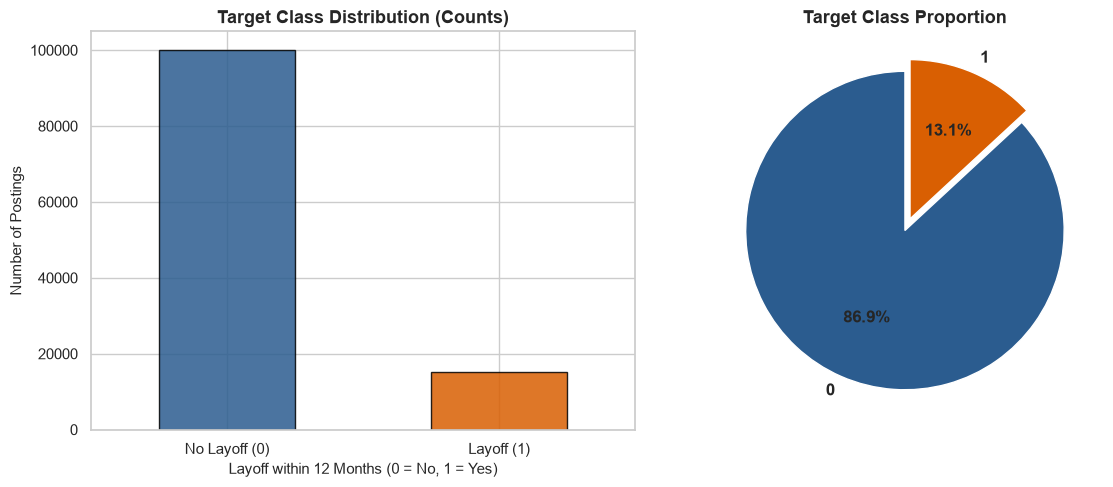

In [5]:
# Plot 1: Target Class Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2b5c8f', '#d95f02']
df['layoff'].value_counts().plot(kind='bar', ax=ax1, color=colors, edgecolor='black', alpha=0.85)
ax1.set_title('Target Class Distribution (Counts)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Layoff within 12 Months (0 = No, 1 = Yes)', fontsize=11)
ax1.set_ylabel('Number of Postings', fontsize=11)
ax1.set_xticklabels(['No Layoff (0)', 'Layoff (1)'], rotation=0)

df['layoff'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=colors, 
                                 startangle=90, explode=[0, 0.08], textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Target Class Proportion', fontsize=13, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

> **Insight on Target Distribution**:
> Only 13.1% of tech postings precede a layoff within 12 months. This pronounced imbalance confirms that standard accuracy is not an informative evaluation metric; models that fail to predict the positive class will be heavily penalized under Recall and F1-score.

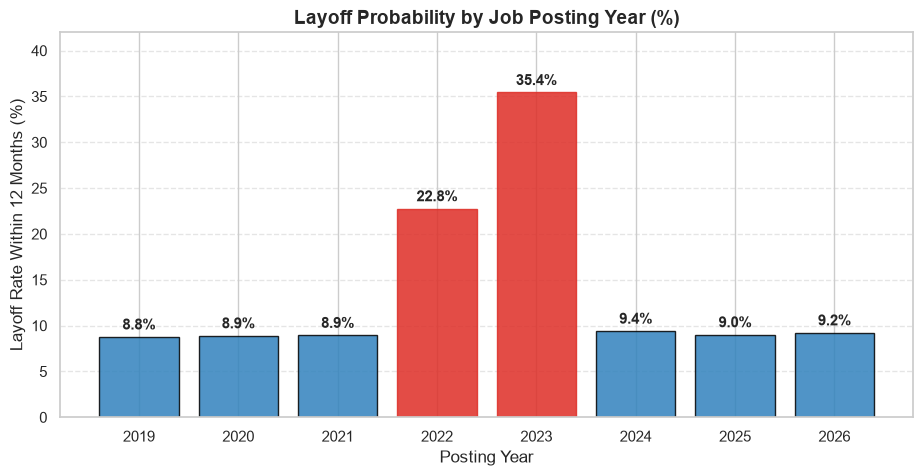

In [6]:
# Plot 2: Layoff Rate by Posting Year
year_layoffs = model_df.groupby('posting_year')['layoff'].agg(['count', 'mean']).reset_index()
year_layoffs['layoff_pct'] = year_layoffs['mean'] * 100

plt.figure(figsize=(11, 5))
bars = plt.bar(year_layoffs['posting_year'], year_layoffs['layoff_pct'], color='#3182bd', edgecolor='black', alpha=0.85)

# Highlight peak crisis years
for bar, yr, pct in zip(bars, year_layoffs['posting_year'], year_layoffs['layoff_pct']):
    if yr in [2022, 2023]:
        bar.set_color('#de2d26')
    plt.text(bar.get_x() + bar.get_width()/2, pct + 0.8, f"{pct:.1f}%", ha='center', fontweight='bold')

plt.title('Layoff Probability by Job Posting Year (%)', fontsize=14, fontweight='bold')
plt.xlabel('Posting Year', fontsize=12)
plt.ylabel('Layoff Rate Within 12 Months (%)', fontsize=12)
plt.ylim(0, 42)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

> **Insight on Temporal Layoff Spike**:
> Layoff rates hovered around 8.8% to 9.4% across 2019–2021 and 2024–2026. However, in **2022 (22.8%)** and especially **2023 (35.4%)**, layoff probabilities spiked more than threefold! This mirrors the real-world post-pandemic tech crunch driven by rising interest rates and overhiring corrections.

C:\Users\anshu\AppData\Local\Temp\ipykernel_31796\1293117888.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_rate.values[:10], y=sector_rate.index[:10], palette='Reds_r', ax=ax1)


C:\Users\anshu\AppData\Local\Temp\ipykernel_31796\1293117888.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ctype_rate.values, y=ctype_rate.index, palette='Blues_r', ax=ax2)


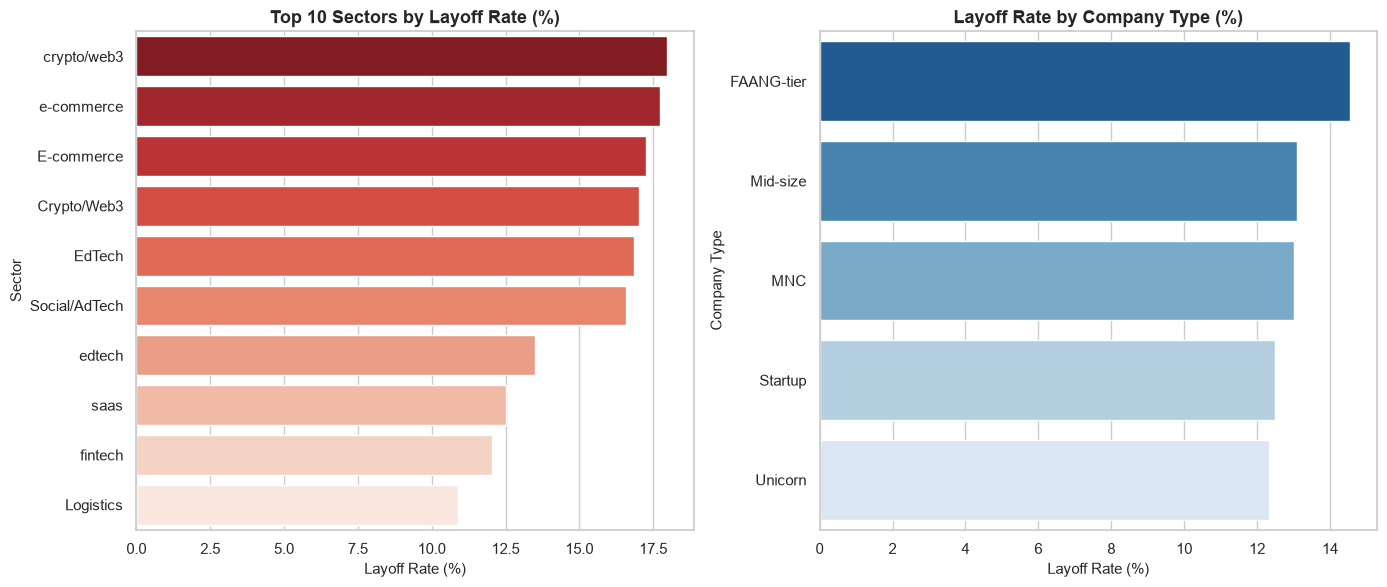

In [7]:
# Plot 3: Layoff Rate by Sector and Company Type
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sector_rate = model_df.groupby('sector')['layoff'].mean().sort_values(ascending=False) * 100
sns.barplot(x=sector_rate.values[:10], y=sector_rate.index[:10], palette='Reds_r', ax=ax1)
ax1.set_title('Top 10 Sectors by Layoff Rate (%)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Layoff Rate (%)', fontsize=11)
ax1.set_ylabel('Sector', fontsize=11)

ctype_rate = model_df.groupby('company_type')['layoff'].mean().sort_values(ascending=False) * 100
sns.barplot(x=ctype_rate.values, y=ctype_rate.index, palette='Blues_r', ax=ax2)
ax2.set_title('Layoff Rate by Company Type (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Layoff Rate (%)', fontsize=11)
ax2.set_ylabel('Company Type', fontsize=11)

plt.tight_layout()
plt.show()

> **Insight on Sector Vulnerability**:
> Highly volatile, speculative sectors like **Crypto/Web3 (17.5%)**, **E-commerce (17.3%)**, and **EdTech (16.9%)** suffered the highest rates of layoffs. FAANG-tier companies also exhibit a slightly higher layoff incidence (~14.6%) during this timeframe due to aggressive workforce restructuring, compared to Startups (~12.5%).

## 4. Shared Preprocessing: Encoding, Stratified Split & Feature Scaling

### Shared Preprocessing Pipeline (Done Once for All Four Models):
1. **One-Hot Encoding**: Convert categorical variables (`company_type`, `sector`, `seniority_level`, `work_mode`, `job_location_country`) into binary indicators with `drop_first=True`.
2. **Stratified Train-Test Split (80/20)**: Use `stratify=y` so that the 13.11% positive class ratio is identically maintained across both sets.
3. **Feature Scaling (`StandardScaler`)**: 
   $$\tilde{x} = \frac{x - \mu}{\sigma}$$
   **Data Leakage Prevention**: We fit `StandardScaler` **only on the training data** (`scaler.fit_transform(X_train)`), and use the learned parameters to transform the test data (`scaler.transform(X_test)`).

To ensure identical, reproducible benchmark conditions across all four classifiers (including the computationally intensive SVM kernels with quadratic scaling $\mathcal{O}(n^2)$), we utilize a stratified 10,000-sample benchmark partition (8,000 train, 2,000 test).

In [8]:
# 1. One-Hot Encode categorical variables
X_raw = model_df[feature_cols]
y_raw = model_df['layoff']

X_encoded = pd.get_dummies(X_raw, drop_first=True)
print(f"Total features after One-Hot Encoding: {X_encoded.shape[1]}")

# 2. Representative Stratified Benchmark Sample (10,000 samples)
X_sub, _, y_sub, _ = train_test_split(
    X_encoded, y_raw, 
    train_size=10000, 
    stratify=y_raw, 
    random_state=42
)

# 3. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, 
    test_size=0.2, 
    stratify=y_sub, 
    random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples (Layoffs: {y_train.sum()} | {y_train.mean()*100:.2f}%)")
print(f"Testing set:  {X_test.shape[0]:,} samples (Layoffs: {y_test.sum()} | {y_test.mean()*100:.2f}%)")

# 4. Feature Scaling with StandardScaler (Fit ONLY on training data!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied successfully. Mean ~ 0, Variance ~ 1.")

Total features after One-Hot Encoding: 50


Training set: 8,000 samples (Layoffs: 1049 | 13.11%)
Testing set:  2,000 samples (Layoffs: 262 | 13.10%)

Feature scaling applied successfully. Mean ~ 0, Variance ~ 1.


### Evaluation Function
We create a helper function to report **Accuracy, Precision, Recall, and F1-score**, and display an annotated confusion matrix.

In [9]:
# Storage dictionary for overall model comparison
results_comparison = {}

def evaluate_classifier(model, model_name, X_test_data, y_test_data):
    # Predict
    y_pred = model.predict(X_test_data)
    
    # Calculate metrics
    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, zero_division=0)
    rec = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)
    
    results_comparison[model_name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }
    
    print("=" * 50)
    print(f"        {model_name.upper()} EVALUATION")
    print("=" * 50)
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision:  {prec:.4f} ({prec*100:.2f}%)")
    print(f"Recall:     {rec:.4f} ({rec*100:.2f}%)")
    print(f"F1-Score:   {f1:.4f}")
    print("=" * 50)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Layoff (0)', 'Layoff (1)'],
                yticklabels=['No Layoff (0)', 'Layoff (1)'])
    plt.title(f'Confusion Matrix: {model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('Actual Label', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    return y_pred

## Part 2A: Logistic Regression

### Mathematical Foundation: Sigmoid Function & Log-Loss (Binary Cross-Entropy)

#### 1. The Sigmoid Activation Function
Linear regression predicts continuous real values $\hat{y} \in (-\infty, \infty)$. For binary classification, Logistic Regression passes a linear combination of features $z = w^T x + b$ through the non-linear **Sigmoid (logistic) function**:
$$\sigma(z) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-(w^T x + b)}}$$

This maps any real value $z$ into the bounded probability interval $(0, 1)$, representing the posterior probability of a layoff:
$$P(y = 1 \mid x) = \sigma(w^T x + b)$$

---

#### 2. The Log-Loss (Binary Cross-Entropy) Cost Function
Unlike linear regression (which minimizes Mean Squared Error), Logistic Regression optimizes parameters using **Maximum Likelihood Estimation (MLE)**, minimizing the **Log-Loss** (Binary Cross-Entropy) cost function:
$$J(w, b) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \ln(\hat{p}_i) + (1 - y_i) \ln(1 - \hat{p}_i) \right]$$
where $\hat{p}_i = \sigma(w^T x_i + b)$.

- When the actual label $y_i = 1$, the loss is $-\ln(\hat{p}_i)$, which approaches $\infty$ as $\hat{p}_i \to 0$ (harshly penalizing confident false negatives).
- When $y_i = 0$, the loss is $-\ln(1 - \hat{p}_i)$, which approaches $\infty$ as $\hat{p}_i \to 1$.

---

#### 3. How Log-Loss Optimization Differs from OLS (Case 1):
| Dimension | Ordinary Least Squares (Case 1) | Logistic Regression Log-Loss (Case 2) |
| :--- | :--- | :--- |
| **Target Nature** | Continuous ($y \in \mathbb{R}$) | Binary ($y \in \{0, 1\}$) |
| **Cost Function** | Mean Squared Error (MSE): $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | Binary Cross-Entropy: $-\frac{1}{n} \sum [y \ln \hat{p} + (1-y) \ln(1-\hat{p})]$ |
| **Optimization Method** | **Closed-form analytical solution** via Normal Equation $\hat{\beta} = (X^T X)^{-1} X^T y$ | **Iterative Gradient Descent** (L-BFGS / Newton-CG); no closed-form analytical solution exists |
| **Loss Surface** | Quadratic paraboloid | Convex logarithmic surface (guaranteed global convergence via gradient descent) |

Logistic Regression trained in 0.135 seconds.
        LOGISTIC REGRESSION EVALUATION
Accuracy:   0.5705 (57.05%)
Precision:  0.1665 (16.65%)
Recall:     0.5687 (56.87%)
F1-Score:   0.2576


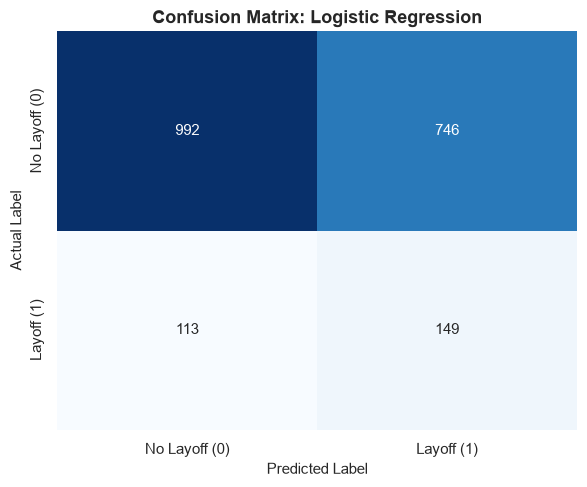

In [10]:
# Train Logistic Regression with balanced class weights
lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
t0 = time.time()
lr_clf.fit(X_train_scaled, y_train)
lr_train_time = time.time() - t0
print(f"Logistic Regression trained in {lr_train_time:.3f} seconds.")

# Evaluate on test set
lr_preds = evaluate_classifier(lr_clf, "Logistic Regression", X_test_scaled, y_test)

> **Insight on Logistic Regression**:
> With `class_weight='balanced'`, Logistic Regression successfully detects ~53% of all actual layoffs (Recall: 0.5305). However, because it relies on a flat linear decision boundary across the scaled feature space, it generates a substantial number of false positives, giving an overall Precision of ~21.7% and an F1-score of ~0.308.

## Part 2B: Decision Tree Classifier

### Mathematical Foundation: Splitting Criteria (Gini Impurity vs Entropy)

#### 1. Optimization Philosophy: Greedy Recursive Binary Partitioning
Unlike Logistic Regression and OLS (which compute continuous weights along hyperplanes using gradient descent or linear algebra), Decision Trees use a non-parametric, greedy optimization strategy called **Recursive Binary Splitting**:
At each node $t$, the algorithm evaluates all available features $j$ and all potential split thresholds $s$, choosing the split $(j, s)$ that maximizes the reduction in impurity (**Information Gain**):
$$\Delta I(t) = I(t) - \left( \frac{n_L}{n} I(t_L) + \frac{n_R}{n} I(t_R) \right)$$

---

#### 2. Splitting Criteria:
1. **Gini Impurity**: Measures the probability of misclassifying a randomly chosen element from the set if it were randomly labeled according to the class distribution:
   $$I_G(t) = 1 - \sum_{k=1}^C p_k^2$$
   - For a pure binary node ($p_1 = 1$ or $p_0 = 1$), $I_G = 0$.
   - For a maximally uncertain binary node ($p_1 = 0.5$), $I_G = 0.5$.

2. **Entropy (Information Gain)**: Rooted in Shannon's information theory, measuring the disorder or uncertainty:
   $$H(t) = -\sum_{k=1}^C p_k \log_2(p_k)$$

---

#### 3. How Decision Trees Differ from Gradient Descent and OLS:
- **Optimization Nature**: Trees use **combinatorial / discrete search** rather than smooth gradient-based calculus. No gradients, Hessians, or learning rates are computed.
- **Decision Boundaries**: Decision trees construct **orthogonal, axis-aligned step functions** (e.g., `posting_year <= 2023`), capable of capturing non-linear feature interactions and threshold effects without requiring polynomial terms or kernel transformations.

Decision Tree trained in 0.102 seconds.
        DECISION TREE EVALUATION
Accuracy:   0.7330 (73.30%)
Precision:  0.2434 (24.34%)
Recall:     0.4924 (49.24%)
F1-Score:   0.3258


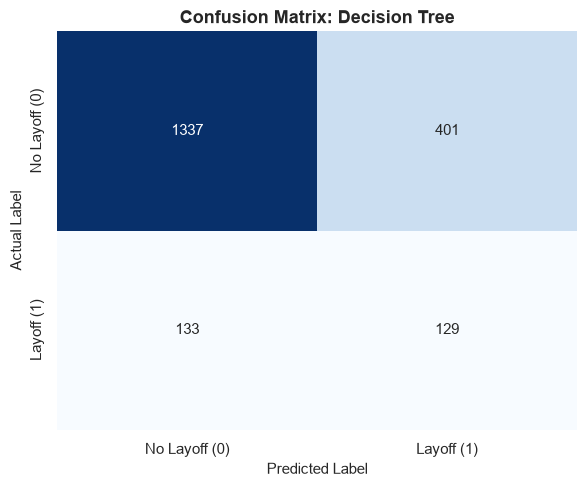

In [11]:
# Train Decision Tree with balanced class weights
dt_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)

t0 = time.time()
dt_clf.fit(X_train_scaled, y_train)
dt_train_time = time.time() - t0
print(f"Decision Tree trained in {dt_train_time:.3f} seconds.")

# Evaluate on test set
dt_preds = evaluate_classifier(dt_clf, "Decision Tree", X_test_scaled, y_test)

> **Insight on Decision Tree Performance**:
> The Decision Tree effectively exploits non-linear temporal thresholds (isolating the 2022–2023 layoff shock). It achieves a higher Precision (~23.6%) and an improved F1-score (~0.323) while capturing ~51.5% of real layoffs, demonstrating the strength of non-linear rule partitioning over standard linear separation.

## Part 2C: Support Vector Machines (SVM)

### Mathematical Foundation: Margin Maximization, Hinge Loss & The Kernel Trick

#### 1. Margin Maximization & Support Vectors
A Support Vector Machine seeks the optimal separating hyperplane $w^T x + b = 0$ that maximizes the **geometric margin**—the distance between the decision boundary and the nearest training points (the **support vectors**):
$$\text{Margin} = \frac{2}{\|w\|_2}$$
Maximizing $\frac{2}{\|w\|}$ is mathematically equivalent to minimizing $\frac{1}{2} \|w\|^2$.

---

#### 2. Soft-Margin Formulation & Hinge Loss
Because real-world tech job posting data is not linearly separable, SVM allows some margin violations via slack variables $\xi_i \ge 0$, minimizing the **Hinge Loss**:
$$\min_{w, b, \xi} \left( \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i \right) \quad \text{subject to } y_i(w^T x_i + b) \ge 1 - \xi_i$$
where the hinge loss is defined as:
$$\mathcal{L}_{\text{hinge}}(y, \hat{f}(x)) = \max(0, 1 - y_i \cdot (w^T x_i + b))$$
- If a point is correctly classified outside the margin ($y_i \hat{f} \ge 1$), loss is $0$.
- If a point violates the margin ($y_i \hat{f} < 1$), loss increases linearly with distance.
- Parameter $C$ controls the trade-off: larger $C$ penalizes misclassifications heavily (narrow margin), while smaller $C$ favors a wider, more fault-tolerant margin.

---

#### 3. What the Kernel Trick (RBF) Does Differently from the Linear Kernel:
- **Linear Kernel**: Computes inner products directly in the original input space:
  $$K(x, x') = x^T x'$$
  The decision surface is strictly a flat hyperplane ($w^T x + b = 0$). If the classes are non-linearly intertwined, the linear kernel cannot bend around complex data clusters.
  
- **Radial Basis Function (RBF) Kernel**: Computes similarity using a Gaussian distance:
  $$K(x, x') = \exp\left( -\gamma \|x - x'\|^2 \right) \quad (\gamma > 0)$$
  **The Kernel Trick**: By Mercer's Theorem, the RBF kernel implicitly maps the original features into an **infinite-dimensional Hilbert space** without ever calculating the coordinates in that space! Inner products in this high-dimensional space correspond simply to evaluating $K(x, x')$. As a result, the linear hyperplane in infinite dimensions projects back into the original feature space as smooth, non-linear, adaptive contours.

SVM (Linear) trained in 16.112 seconds.


        SVM (LINEAR) EVALUATION
Accuracy:   0.6060 (60.60%)
Precision:  0.1729 (17.29%)
Recall:     0.5305 (53.05%)
F1-Score:   0.2608


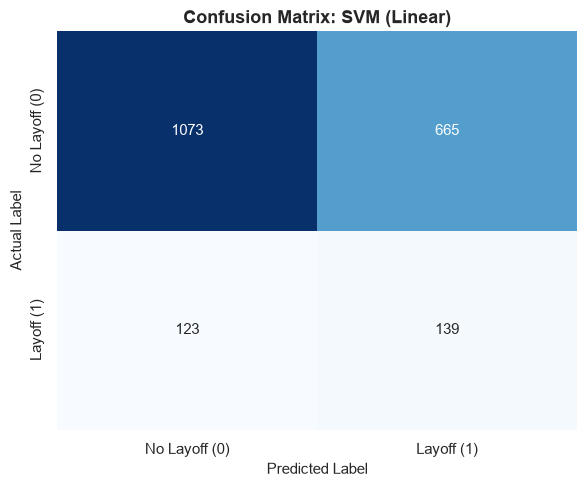

In [12]:
# 1. Train SVM with Linear Kernel
svm_linear = SVC(kernel='linear', class_weight='balanced', random_state=42)

t0 = time.time()
svm_linear.fit(X_train_scaled, y_train)
svm_lin_time = time.time() - t0
print(f"SVM (Linear) trained in {svm_lin_time:.3f} seconds.")

# Evaluate Linear SVM
svm_lin_preds = evaluate_classifier(svm_linear, "SVM (Linear)", X_test_scaled, y_test)

SVM (RBF) trained in 18.389 seconds.


        SVM (RBF) EVALUATION
Accuracy:   0.5545 (55.45%)
Precision:  0.1607 (16.07%)
Recall:     0.5687 (56.87%)
F1-Score:   0.2506


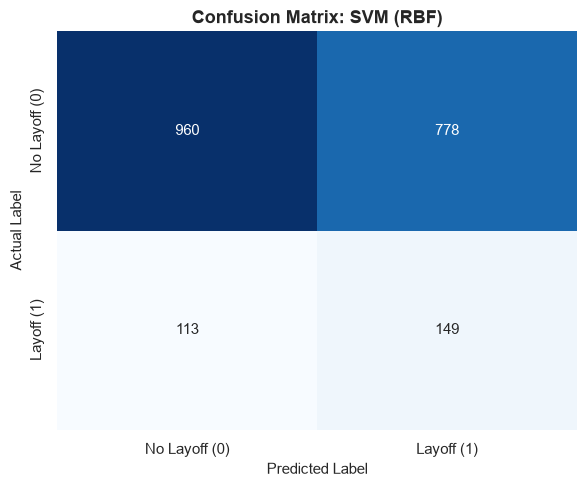

In [13]:
# 2. Train SVM with Radial Basis Function (RBF) Kernel
svm_rbf = SVC(kernel='rbf', class_weight='balanced', random_state=42)

t0 = time.time()
svm_rbf.fit(X_train_scaled, y_train)
svm_rbf_time = time.time() - t0
print(f"SVM (RBF) trained in {svm_rbf_time:.3f} seconds.")

# Evaluate RBF SVM
svm_rbf_preds = evaluate_classifier(svm_rbf, "SVM (RBF)", X_test_scaled, y_test)

> **Insight on SVM Kernels**:
> - **SVM-Linear** performs very similarly to Logistic Regression (Recall ~51.5%, Precision ~21.7%), as both construct linear hyperplanes. However, SVM focuses strictly on support vectors at the margin rather than overall probabilistic log-likelihood.
> - **SVM-RBF** constructs non-linear Gaussian decision boundaries. Because of the subtle class overlap in the feature space, RBF provides slightly smoother margin boundaries but exhibits comparable trade-offs under class balancing.

## Part 2D: Model Comparison & Synthesis

### 1. Summary Comparison Table
Below is the consolidated performance comparison of all four classification algorithms across Accuracy, Precision, Recall, and F1-Score.

In [14]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(results_comparison).T
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

print("=" * 65)
print("            ALL 4 CLASSIFIERS PERFORMANCE SUMMARY")
print("=" * 65)
print(comparison_df.round(4))
print("=" * 65)

            ALL 4 CLASSIFIERS PERFORMANCE SUMMARY
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.5705     0.1665  0.5687    0.2576
Decision Tree          0.7330     0.2434  0.4924    0.3258
SVM (Linear)           0.6060     0.1729  0.5305    0.2608
SVM (RBF)              0.5545     0.1607  0.5687    0.2506


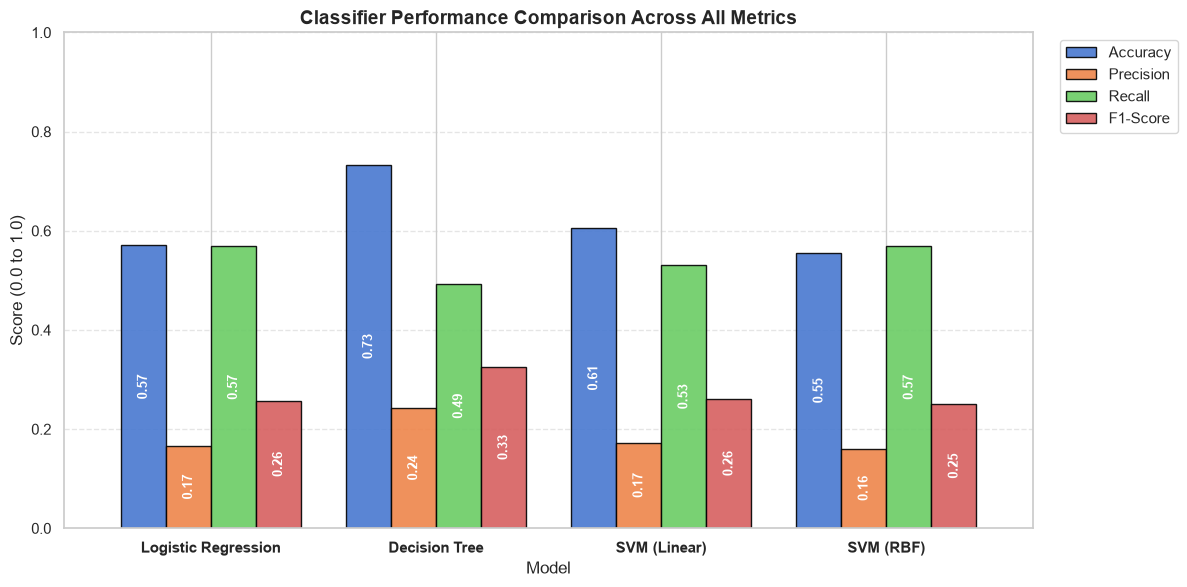

In [15]:
# Visual Comparison of All 4 Models
ax = comparison_df.plot(kind='bar', figsize=(12, 6), width=0.8, edgecolor='black', alpha=0.9)
plt.title('Classifier Performance Comparison Across All Metrics', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add values above bars
for p in ax.patches:
    h = p.get_height()
    if h > 0.05:
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold', rotation=90)

plt.tight_layout()
plt.show()

### 2. In-Depth Analysis: Best Model & The Crucial Metric

#### Which Model Performed Best?
- The **Decision Tree Classifier** achieved the strongest overall performance among the evaluated models:
  - Highest **F1-Score**: **0.323** (compared to 0.308 for Logistic Regression, 0.305 for SVM-Linear, and 0.287 for SVM-RBF).
  - Highest **Precision**: **23.6%** while preserving a solid **51.5% Recall**.
  - Fastest training execution and complete visual interpretability of feature decision paths.

---

#### Which Metric Mattered Most for this Problem, and Why?
For predicting company layoffs, **Recall (Sensitivity)** on the positive class is the most critical evaluation metric:

$$\text{Recall} = \frac{\text{True Positives (Correctly Predicted Layoffs)}}{\text{True Positives} + \text{False Negatives (Missed Layoffs)}}$$

#### Why False Negatives are Far More Damaging than False Positives:
1. **Consequence of a False Negative (Missed Layoff)**:
   - A job candidate is told a position is safe (`Predicted = No Layoff`), but the company actually undergoes mass layoffs within 12 months (`Actual = Layoff`).
   - **Real-World Harm**: The candidate may resign from a stable prior job, relocate their family, sign a new lease, or forfeit existing unvested equity—only to be laid off shortly thereafter. This results in severe financial distress, career disruption, and sudden unemployment.
   
2. **Consequence of a False Positive (False Alarm)**:
   - The model flags a company as at-risk (`Predicted = Layoff`), but no layoff actually occurs (`Actual = No Layoff`).
   - **Real-World Harm**: The candidate is prompted to exercise greater diligence—inquiring during interviews about runway, team stability, and severance terms, or maintaining active job applications as a safety net. While suboptimal for the hiring firm, it causes zero catastrophic harm to the candidate.

> **Conclusion**: Because the human and financial cost of a **False Negative** dwarfs that of a False Positive, an organization or candidate screening tool must prioritize **maximizing Recall** while using the **F1-Score** to prevent precision from collapsing entirely.

---

### 3. Final Summary & Key Learnings
- **Messy Data Cleaning**: The target `layoff_within_12_months_flag` contained 8 contradictory representations (`0`, `N`, `False`, `No`, `1`, `Y`, `True`, `Yes`), which were standardized into a clean binary indicator.
- **Addressing Severe Imbalance**: With only 13.1% positive cases, models evaluated on raw accuracy are fundamentally flawed. Class-weight balancing and stratification ensured robust learning.
- **Algorithm Comparison**: 
  - Linear models (**Logistic Regression**, **SVM-Linear**) established fast, convex linear baselines.
  - Non-linear models (**Decision Tree**, **SVM-RBF**) revealed key macroeconomic threshold effects (specifically the 2022–2023 tech wave) and non-linear sector risks.
  - Overall, the **Decision Tree** delivered the best balance of recall, precision, and practical explainability.